# 1. Exploratory Data Analysis
**Dataset:** World Happiness Report 2026 (WHR26)  
Källa: https://worldhappiness.report/  
2 116 rader totalt; 1 013 med kompletta features (år 2019–2025).

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Fungerar oavsett om CWD är project root eller notebooks/
_here = Path().resolve()
DATA_DIR = _here / 'data' if (_here / 'data').exists() else _here.parent / 'data'

df = pd.read_csv(DATA_DIR / 'cleaned_data.csv')
print('Shape:', df.shape)
df.head()

Shape: (1013, 13)


,Year,Rank,country,happiness_score,ci_lower,ci_upper,gdp,social_support,health,freedom,generosity,corruption,dystopia_residual
0,2025,1,Finland,7.764,7.690,7.837,1.915,1.638,0.939,1.105,0.093,0.491,1.582
1,2025,2,Iceland,7.540,7.449,7.630,1.971,1.720,0.996,1.105,0.187,0.187,1.373
2,2025,3,Denmark,7.539,7.446,7.631,1.986,1.633,0.930,1.081,0.125,0.474,1.310
3,2025,4,Costa Rica,7.439,7.356,7.522,1.697,1.483,0.739,1.101,0.059,0.122,2.236
4,2025,5,Sweden,7.255,7.172,7.337,1.950,1.570,1.027,1.070,0.149,0.447,1.041


In [8]:
df.describe()

,Year,Rank,happiness_score,ci_lower,ci_upper,gdp,social_support,health,freedom,generosity,corruption,dystopia_residual
count,1013.000000,1013.000000,1013.000000,1013.000000,1013.000000,1013.000000,1013.000000,1013.000000,1013.000000,1013.000000,1013.000000,1013.000000
mean,2021.960513,73.438302,5.552652,5.438452,5.666818,1.266128,1.094809,0.553158,0.609201,0.147717,0.144717,1.736935
std,2.022214,42.418107,1.127344,1.144839,1.110980,0.464868,0.357753,0.230177,0.212121,0.084417,0.118731,0.657497
min,2019.000000,1.000000,1.364000,1.301000,1.427000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-0.295000
25%,2020.000000,37.000000,4.729300,4.614000,4.861000,0.944000,0.865000,0.389000,0.471000,0.089000,0.063000,1.305000
50%,2022.000000,73.000000,5.714000,5.599000,5.819000,1.306000,1.135000,0.560000,0.602000,0.134000,0.113000,1.765000
75%,2024.000000,110.000000,6.387400,6.294000,6.490000,1.636000,1.378644,0.712000,0.735000,0.196000,0.181000,2.178000
max,2025.000000,153.000000,7.842000,7.780000,7.904000,2.209000,1.840000,1.238000,1.147000,0.569814,0.587000,3.482000


In [9]:
print('Saknade värden:')
print(df.isnull().sum())

Saknade värden:
Year                 0
Rank                 0
country              0
happiness_score      0
ci_lower             0
ci_upper             0
gdp                  0
social_support       0
health               0
freedom              0
generosity           0
corruption           0
dystopia_residual    0
dtype: int64


In [10]:
# Antal länder per år
print(df.groupby('Year')['country'].count())

Year
2019    153
2020    149
2021    146
2022    136
2023    140
2024    144
2025    145
Name: country, dtype: int64


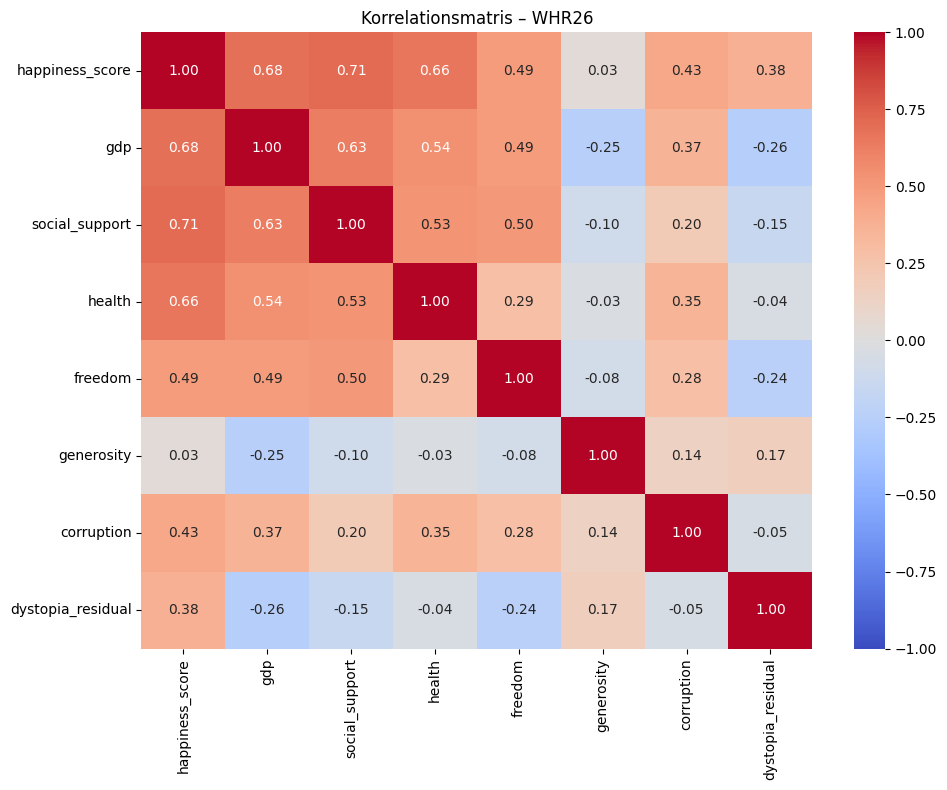

In [11]:
FEATURE_COLS = ['gdp', 'social_support', 'health', 'freedom', 'generosity', 'corruption', 'dystopia_residual']

plt.figure(figsize=(10, 8))
corr = df[['happiness_score'] + FEATURE_COLS].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Korrelationsmatris – WHR26')
plt.tight_layout()
plt.savefig(DATA_DIR / 'correlation_matrix.png', dpi=150)
plt.show()

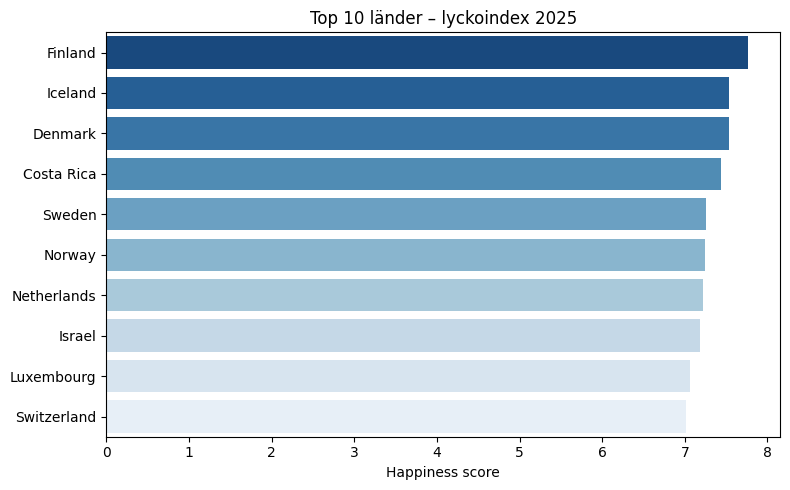

In [12]:
latest = df[df['Year'] == df['Year'].max()].sort_values('Rank')
plt.figure(figsize=(8, 5))
sns.barplot(data=latest.head(10), x='happiness_score', y='country', palette='Blues_r', hue='country', legend=False)
plt.title(f'Top 10 länder – lyckoindex {df["Year"].max()}')
plt.xlabel('Happiness score')
plt.ylabel('')
plt.tight_layout()
plt.savefig(DATA_DIR / 'top10_countries.png', dpi=150)
plt.show()